In [1]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]  # or any installed font


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
# -------------------------------
# CSV LOCATION 
# -------------------------------
CSV_DIR = "./CSV FILES"
SAVE_DIR = "./PNG Files(TimesNewRoman)"
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------------
# Load CSV files
# -------------------------------
df_full = pd.read_csv(f"{CSV_DIR}/training_summary.csv")

epochs = df_full["epoch"]
train_loss = df_full["train_loss"]
phi = df_full["phi_star"]

print("CSV loaded successfully")
df_full.head()


CSV loaded successfully


,epoch,train_loss,val_loss,phi_star
0,1,5.198182,5.309431,0.282961
1,2,5.196129,5.302665,0.318590
2,3,5.170352,5.300679,0.318590
3,4,5.161626,5.297832,0.422823
4,5,5.150740,5.291668,0.422823


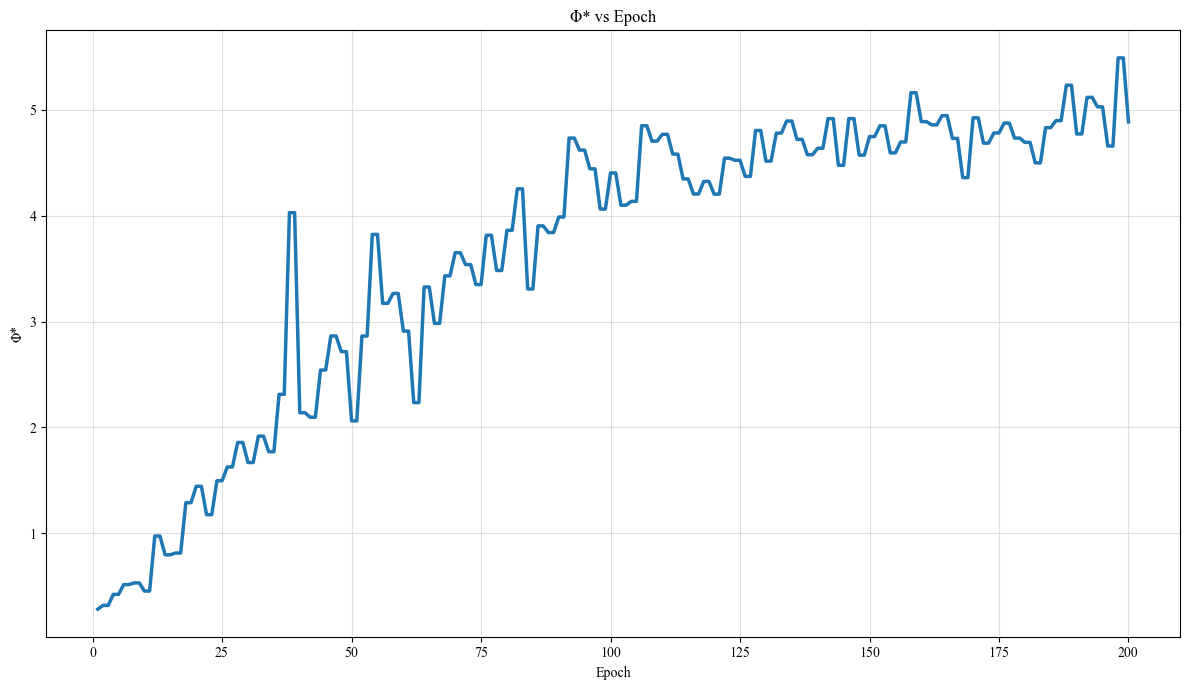

In [11]:
plt.figure(figsize=(12, 7))
plt.plot(epochs, phi, linewidth=2.5)
plt.xlabel("Epoch")
plt.ylabel("Φ*")
plt.title("Φ* vs Epoch")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/phi_vs_epoch.png", dpi=300)
plt.show()


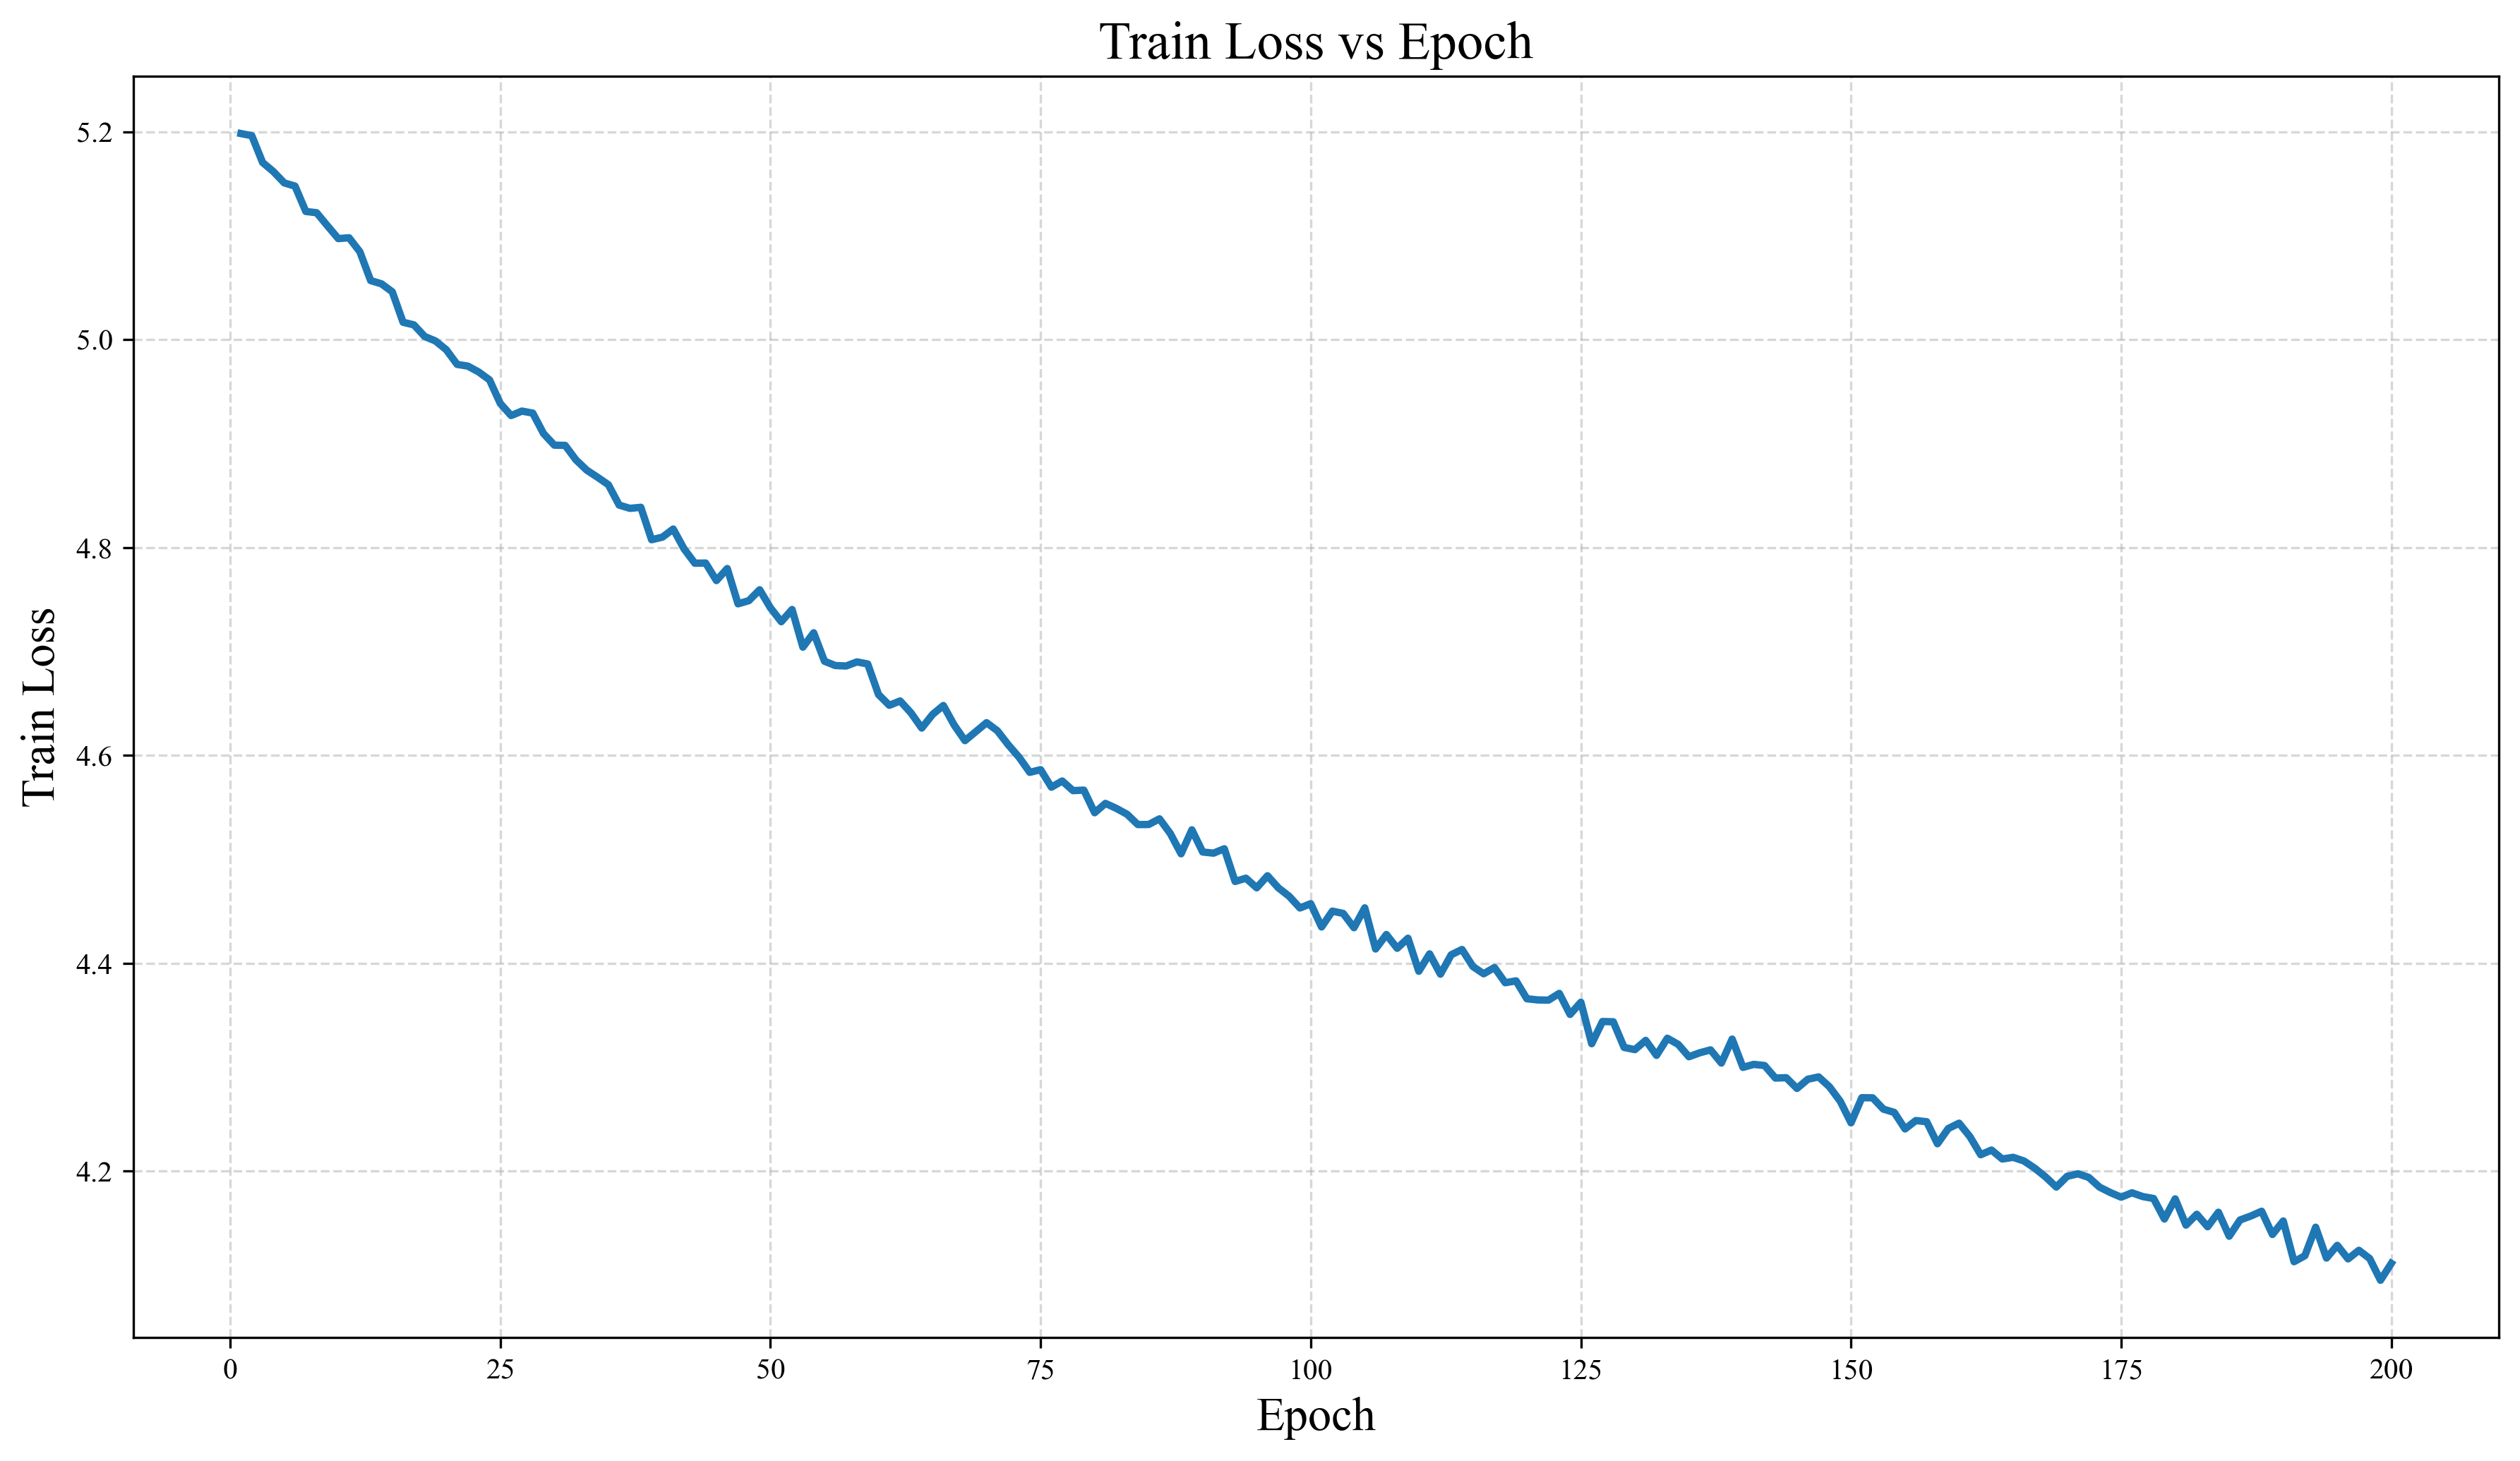

✅ Train Loss vs Epoch plot saved successfully!


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

# -------------------------------
# Safety checks (IMPORTANT)
# -------------------------------
epochs = np.asarray(epochs, dtype=float)
train_loss = np.asarray(train_loss, dtype=float)

if len(epochs) == 0 or len(train_loss) == 0:
    raise ValueError("ERROR: epochs or train_loss is empty!")

if len(epochs) != len(train_loss):
    raise ValueError("ERROR: epochs and train_loss length mismatch!")

# Remove NaN / Inf values safely
mask = np.isfinite(train_loss)
epochs = epochs[mask]
train_loss = train_loss[mask]

# -------------------------------
# Auto y-limits (prevents blank plot)
# -------------------------------
y_min = train_loss.min()
y_max = train_loss.max()
padding = (y_max - y_min) * 0.05 if y_max > y_min else 0.1

# -------------------------------
# Create plot
# -------------------------------
plt.figure(figsize=(12, 7), dpi=300)

plt.plot(
    epochs,
    train_loss,
    linewidth=2.5
)

plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Train Loss", fontsize=16)
plt.title("Train Loss vs Epoch", fontsize=18)

plt.ylim(y_min - padding, y_max + padding)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

# -------------------------------
# Save BEFORE show
# -------------------------------
os.makedirs(SAVE_DIR, exist_ok=True)
plt.savefig(
    f"{SAVE_DIR}/train_loss_vs_epoch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Train Loss vs Epoch plot saved successfully!")


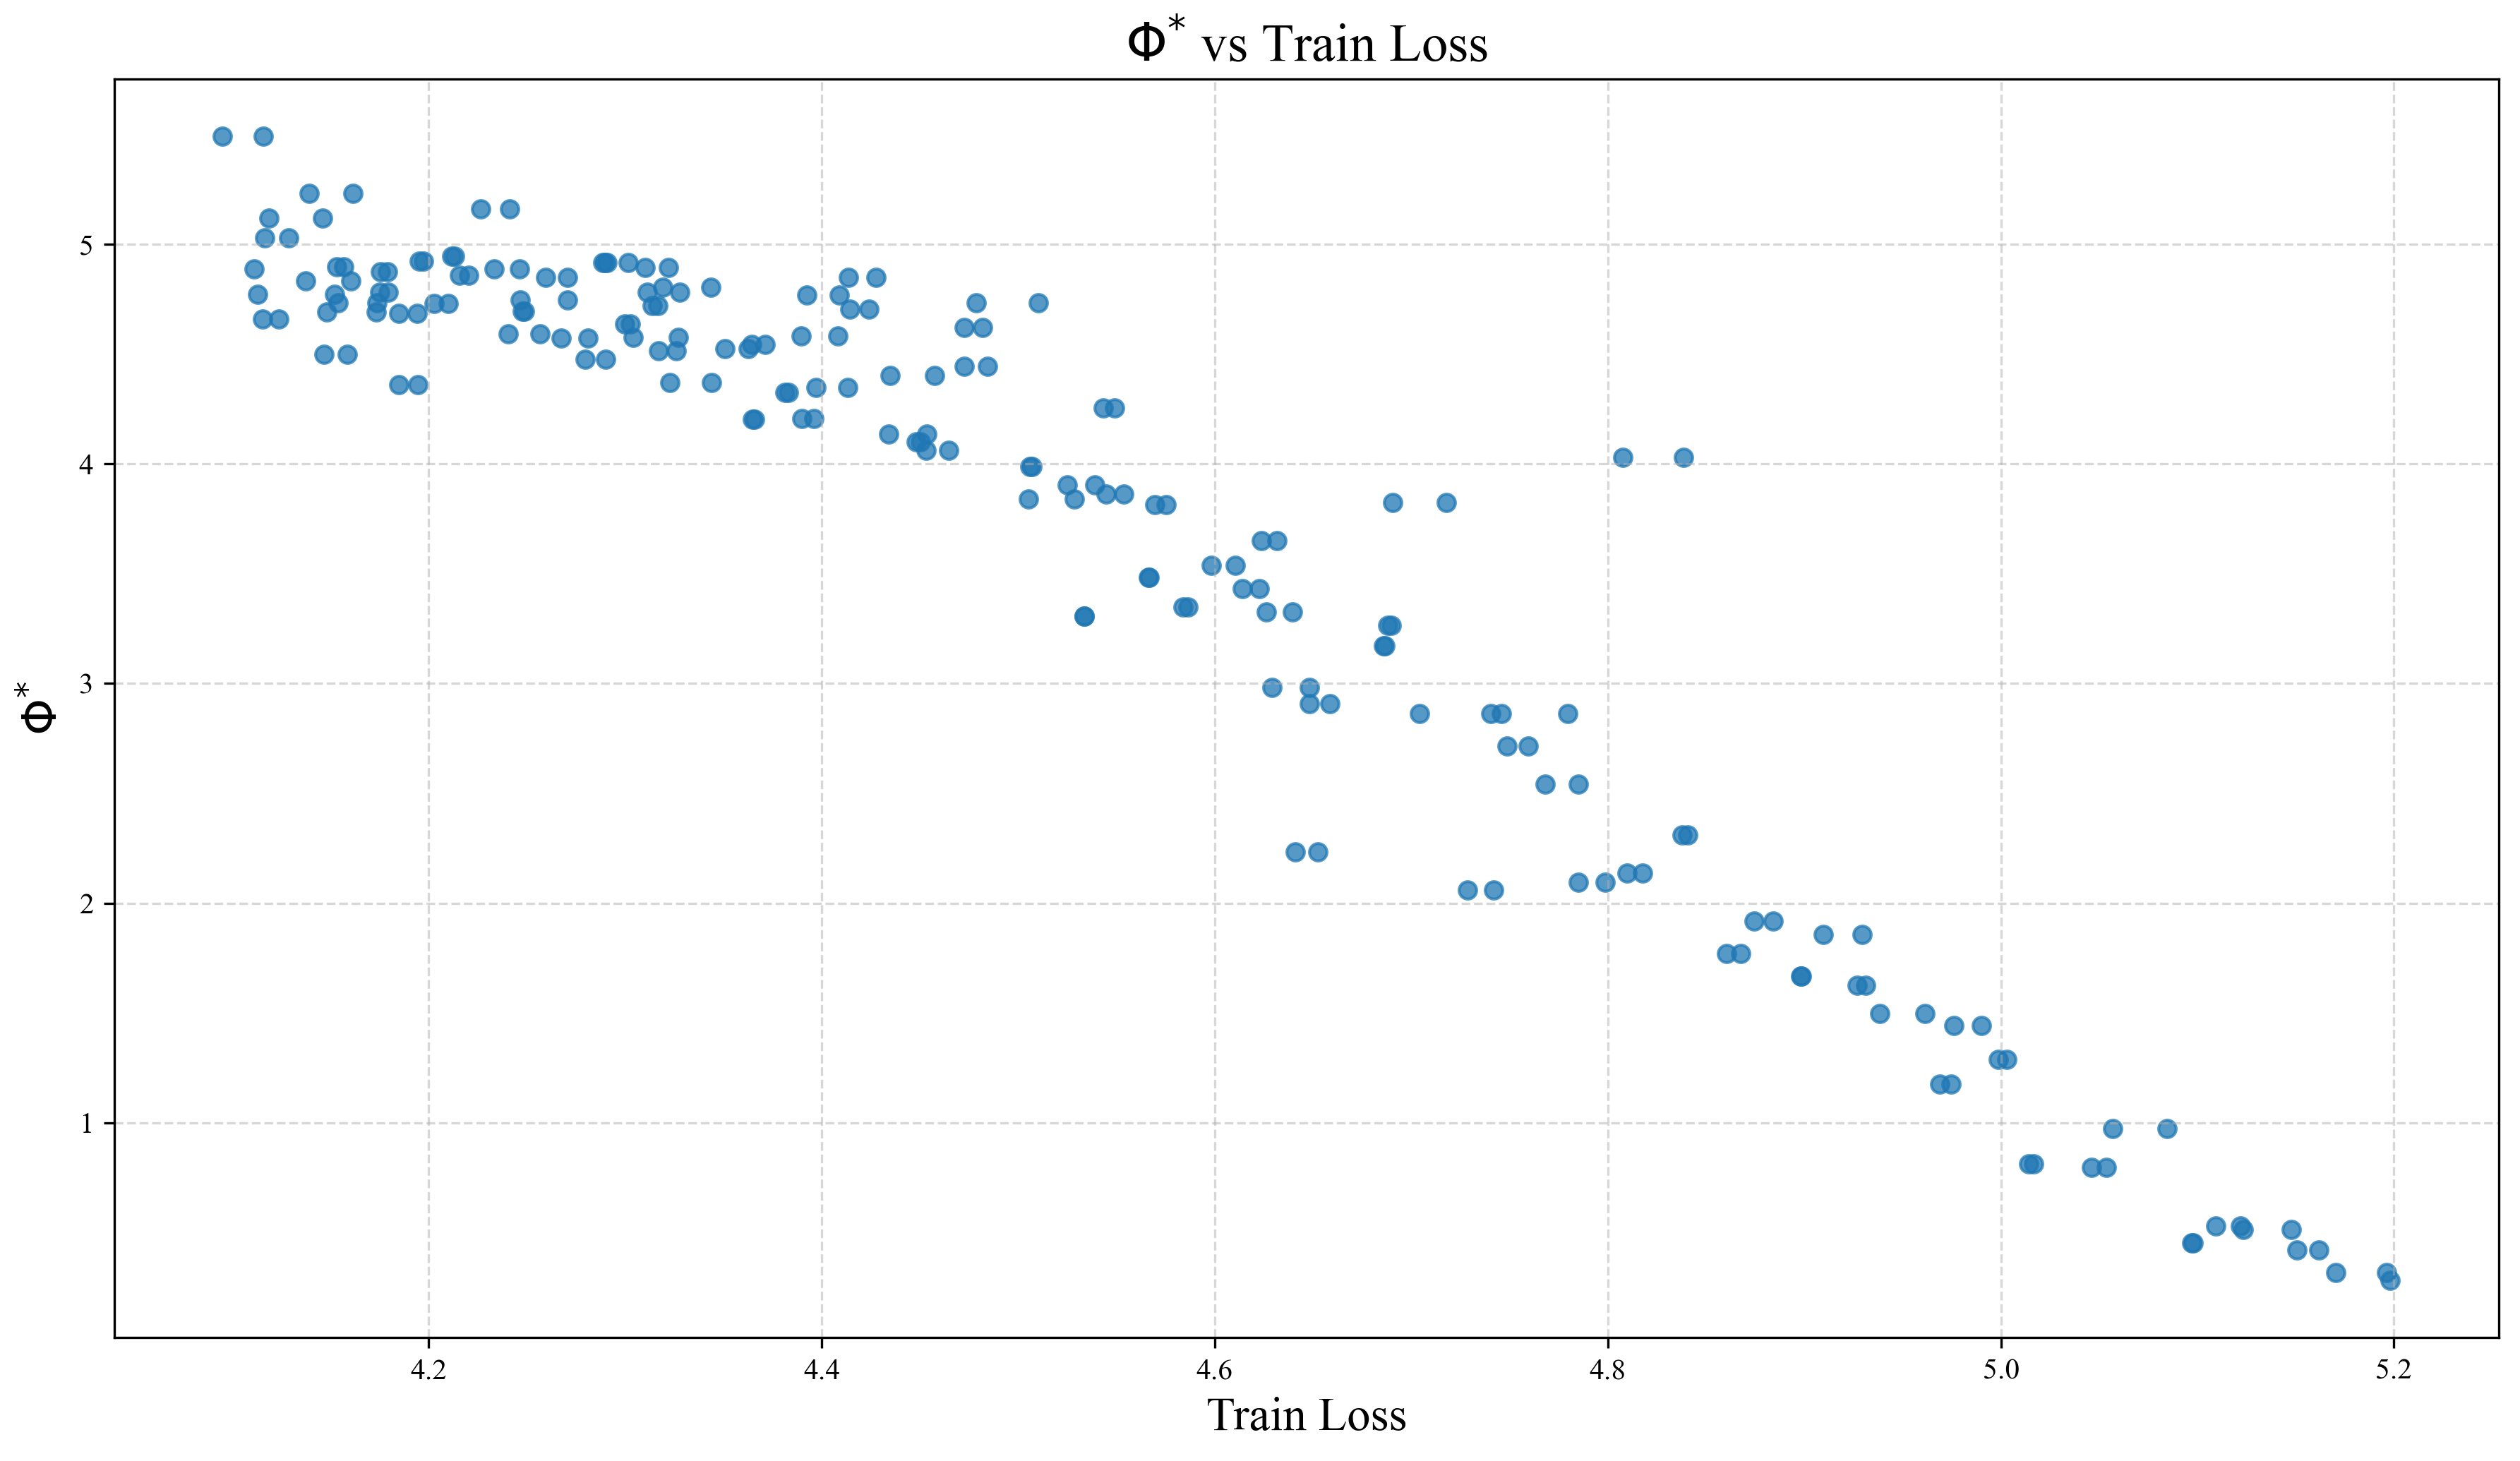

✅ Φ* vs Train Loss plot saved successfully!


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os

# -------------------------------
# Safety checks
# -------------------------------
train_loss = np.asarray(train_loss, dtype=float)
phi = np.asarray(phi, dtype=float)

if len(train_loss) == 0 or len(phi) == 0:
    raise ValueError("ERROR: train_loss or phi is empty!")

if len(train_loss) != len(phi):
    raise ValueError("ERROR: train_loss and phi length mismatch!")

# Remove NaN / Inf
mask = np.isfinite(train_loss) & np.isfinite(phi)
train_loss = train_loss[mask]
phi = phi[mask]


# -------------------------------
# Create figure
# -------------------------------
plt.figure(figsize=(12, 7), dpi=300)

plt.scatter(
    train_loss,
    phi,
    s=35,
    alpha=0.75
)

plt.xlabel("Train Loss", fontsize=16)
plt.ylabel(r"$\Phi^{*}$", fontsize=16)
plt.title(r"$\Phi^{*}$ vs Train Loss", fontsize=18)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

# -------------------------------
# Save
# -------------------------------
os.makedirs(SAVE_DIR, exist_ok=True)
plt.savefig(
    f"{SAVE_DIR}/phi_vs_train_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Φ* vs Train Loss plot saved successfully!")
